In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/NewsGuard"

day6_artifacts = {
    "Model Comparison CSV":
        f"{BASE}/results/day_06_model_comparison.csv",

    "Model Comparison Joblib":
        f"{BASE}/results/day_06_model_comparison.joblib",

    "XGBoost GridSearch CSV":
        f"{BASE}/results/day_06_xgboost_gridsearch.csv",

    "Best Tuned XGBoost":
        f"{BASE}/results/day_06_xgboost_best_tuned.joblib",

    "Gradient Boosting Features":
        f"{BASE}/features/combined/X_train_combined.npz",

    "Day 5 Baseline Results":
        f"{BASE}/results/day_05_baseline_results.csv"
}

print("DAY 7 — DRIVE MOUNT & DAY 6 ARTIFACT VERIFICATION")
print("=" * 70)

print("\nGoogle Drive:")
print("✅ Mounted")

print("\nDay 6 Artifacts:")
all_present = True

for name, path in day6_artifacts.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌"
    print(f"{status} {name}")

    if not exists:
        all_present = False

print("\n" + "=" * 70)

assert all_present, "❌ One or more required Day 6 artifacts are missing."

print("✅ ALL REQUIRED DAY 6 ARTIFACTS VERIFIED")
print("✅ DAY 7 READY TO BEGIN")

Mounted at /content/drive
DAY 7 — DRIVE MOUNT & DAY 6 ARTIFACT VERIFICATION

Google Drive:
✅ Mounted

Day 6 Artifacts:
✅ Model Comparison CSV
✅ Model Comparison Joblib
✅ XGBoost GridSearch CSV
✅ Best Tuned XGBoost
✅ Gradient Boosting Features
✅ Day 5 Baseline Results

✅ ALL REQUIRED DAY 6 ARTIFACTS VERIFIED
✅ DAY 7 READY TO BEGIN


In [2]:
# CELL 2 — RESTORE DAY 7 EVALUATION DATA

import os
import numpy as np
import pandas as pd
import joblib
from scipy import sparse
from sklearn.feature_selection import SelectKBest, chi2

BASE = "/content/drive/MyDrive/NewsGuard"

print("DAY 7 — RESTORING EVALUATION DATA")
print("=" * 70)

# -----------------------------
# Load labels
# -----------------------------
train_df = pd.read_csv(f"{BASE}/data/splits/train.csv")
val_df = pd.read_csv(f"{BASE}/data/splits/validation.csv")
test_df = pd.read_csv(f"{BASE}/data/splits/test.csv")

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

# -----------------------------
# Load TF-IDF features
# -----------------------------
X_train_tfidf = sparse.load_npz(
    f"{BASE}/features/tfidf/X_train_tfidf.npz"
)

X_val_tfidf = sparse.load_npz(
    f"{BASE}/features/tfidf/X_validation_tfidf.npz"
)

X_test_tfidf = sparse.load_npz(
    f"{BASE}/features/tfidf/X_test_tfidf.npz"
)

# -----------------------------
# Load auxiliary features
# -----------------------------
X_train_aux = np.load(
    f"{BASE}/features/auxiliary/X_train_auxiliary.npy"
)

X_val_aux = np.load(
    f"{BASE}/features/auxiliary/X_validation_auxiliary.npy"
)

X_test_aux = np.load(
    f"{BASE}/features/auxiliary/X_test_auxiliary.npy"
)

# -----------------------------
# Recreate Day 6 GB/XGBoost
# feature selection
# -----------------------------
selector_gb = SelectKBest(
    score_func=chi2,
    k=500
)

X_train_tfidf_gb = selector_gb.fit_transform(
    X_train_tfidf,
    y_train
)

X_val_tfidf_gb = selector_gb.transform(
    X_val_tfidf
)

X_test_tfidf_gb = selector_gb.transform(
    X_test_tfidf
)

# -----------------------------
# Combine TF-IDF + auxiliary
# -----------------------------
X_train_gb = sparse.hstack(
    [
        X_train_tfidf_gb,
        sparse.csr_matrix(X_train_aux)
    ],
    format="csr"
)

X_val_gb = sparse.hstack(
    [
        X_val_tfidf_gb,
        sparse.csr_matrix(X_val_aux)
    ],
    format="csr"
)

X_test_gb = sparse.hstack(
    [
        X_test_tfidf_gb,
        sparse.csr_matrix(X_test_aux)
    ],
    format="csr"
)

print("\nShapes:")
print(f"Train : {X_train_gb.shape}")
print(f"Val   : {X_val_gb.shape}")
print(f"Test  : {X_test_gb.shape}")

print("\nLabels:")
print(f"Train : {y_train.shape}")
print(f"Val   : {y_val.shape}")
print(f"Test  : {y_test.shape}")

assert X_train_gb.shape == (31282, 615)
assert X_val_gb.shape == (3910, 615)
assert X_test_gb.shape == (3911, 615)

assert len(y_train) == 31282
assert len(y_val) == 3910
assert len(y_test) == 3911

print("\n" + "=" * 70)
print("✅ DAY 7 EVALUATION DATA RESTORED")
print("✅ BEST XGBOOST FEATURE SPACE RECREATED")
print("✅ TRAIN / VALIDATION / TEST SHAPES VERIFIED")
print("✅ READY FOR HELD-OUT MODEL EVALUATION")

DAY 7 — RESTORING EVALUATION DATA

Shapes:
Train : (31282, 615)
Val   : (3910, 615)
Test  : (3911, 615)

Labels:
Train : (31282,)
Val   : (3910,)
Test  : (3911,)

✅ DAY 7 EVALUATION DATA RESTORED
✅ BEST XGBOOST FEATURE SPACE RECREATED
✅ TRAIN / VALIDATION / TEST SHAPES VERIFIED
✅ READY FOR HELD-OUT MODEL EVALUATION


In [3]:
# CELL 3 — BEST XGBOOST HELD-OUT EVALUATION

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("DAY 7 — BEST XGBOOST HELD-OUT EVALUATION")
print("=" * 70)

# Load best tuned XGBoost from Day 6
best_xgb = joblib.load(
    f"{BASE}/results/day_06_xgboost_best_tuned.joblib"
)

print("✅ Best tuned XGBoost loaded")

# --------------------------------------------------
# Validation Set
# --------------------------------------------------

y_val_pred = best_xgb.predict(X_val_gb)
y_val_prob = best_xgb.predict_proba(X_val_gb)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_prob)

print("\nVALIDATION RESULTS")
print("-" * 70)
print(f"Accuracy : {val_accuracy:.6f}")
print(f"Precision: {val_precision:.6f}")
print(f"Recall   : {val_recall:.6f}")
print(f"F1 Score : {val_f1:.6f}")
print(f"ROC-AUC  : {val_roc_auc:.6f}")

# --------------------------------------------------
# Test Set
# --------------------------------------------------

y_test_pred = best_xgb.predict(X_test_gb)
y_test_prob = best_xgb.predict_proba(X_test_gb)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("\nTEST RESULTS")
print("-" * 70)
print(f"Accuracy : {test_accuracy:.6f}")
print(f"Precision: {test_precision:.6f}")
print(f"Recall   : {test_recall:.6f}")
print(f"F1 Score : {test_f1:.6f}")
print(f"ROC-AUC  : {test_roc_auc:.6f}")

# --------------------------------------------------
# Classification Report
# --------------------------------------------------

print("\nTEST CLASSIFICATION REPORT")
print("-" * 70)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Fake", "Real"],
        digits=4
    )
)

print("=" * 70)
print("✅ HELD-OUT VALIDATION + TEST EVALUATION COMPLETED")

DAY 7 — BEST XGBOOST HELD-OUT EVALUATION
✅ Best tuned XGBoost loaded

VALIDATION RESULTS
----------------------------------------------------------------------
Accuracy : 0.996675
Precision: 0.994831
Recall   : 0.999056
F1 Score : 0.996939
ROC-AUC  : 0.999757

TEST RESULTS
----------------------------------------------------------------------
Accuracy : 0.997187
Precision: 0.995769
Recall   : 0.999057
F1 Score : 0.997410
ROC-AUC  : 0.999780

TEST CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake     0.9989    0.9950    0.9969      1791
        Real     0.9958    0.9991    0.9974      2120

    accuracy                         0.9972      3911
   macro avg     0.9973    0.9970    0.9972      3911
weighted avg     0.9972    0.9972    0.9972      3911

✅ HELD-OUT VALIDATION + TEST EVALUATION COMPLETED


DAY 7 — TEST CONFUSION MATRIX

Confusion Matrix:
[[1782    9]
 [   2 2118]]


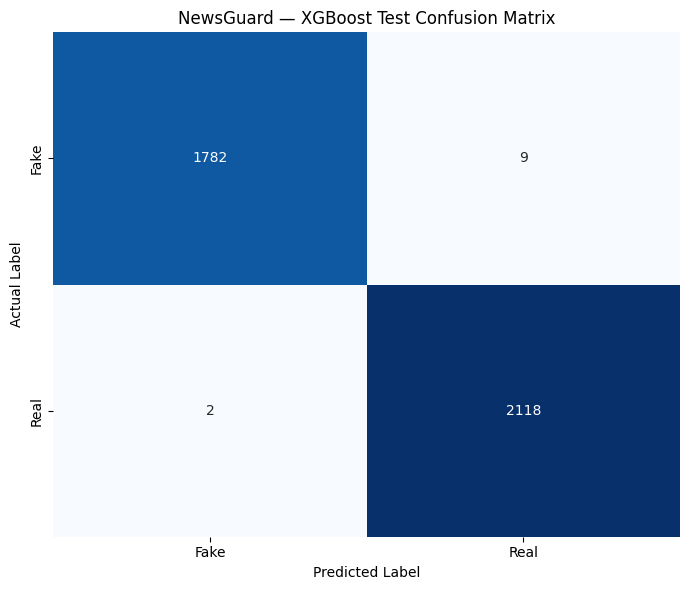


✅ Confusion matrix image saved:
/content/drive/MyDrive/NewsGuard/results/day_07/confusion_matrix_xgboost_test.png
✅ DAY 7 RESULT IMAGE GENERATED


In [4]:
# CELL 4 — CONFUSION MATRIX

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("DAY 7 — TEST CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print(cm)

# Create results directory
results_dir = f"{BASE}/results/day_07"
os.makedirs(results_dir, exist_ok=True)

# Plot
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"],
    cbar=False
)

plt.title("NewsGuard — XGBoost Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

# Save image
cm_path = f"{results_dir}/confusion_matrix_xgboost_test.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")

plt.show()

print("\n" + "=" * 70)
print(f"✅ Confusion matrix image saved:")
print(cm_path)
print("✅ DAY 7 RESULT IMAGE GENERATED")

DAY 7 — TEST ROC CURVE

ROC-AUC: 0.999780


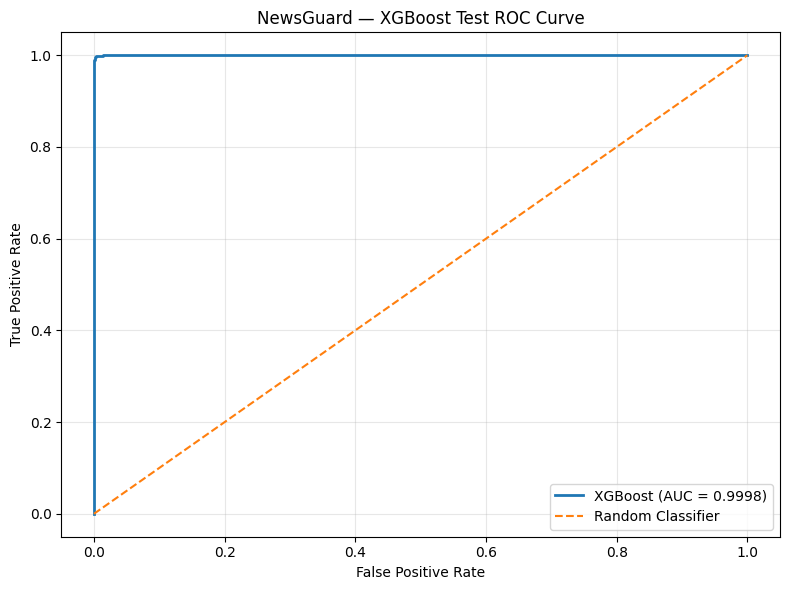


✅ ROC curve image saved:
/content/drive/MyDrive/NewsGuard/results/day_07/roc_curve_xgboost_test.png
✅ ROC-AUC RESULT IMAGE GENERATED


In [5]:
# CELL 5 — ROC CURVE + AUC

from sklearn.metrics import roc_curve, auc

print("DAY 7 — TEST ROC CURVE")
print("=" * 70)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

print(f"\nROC-AUC: {roc_auc:.6f}")

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("NewsGuard — XGBoost Test ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save image
roc_path = f"{results_dir}/roc_curve_xgboost_test.png"

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print(f"✅ ROC curve image saved:")
print(roc_path)
print("✅ ROC-AUC RESULT IMAGE GENERATED")

DAY 7 — MODEL COMPARISON VISUALIZATION

Day 6 models:
                 Model  CV_Accuracy  CV_Precision  CV_Recall     CV_F1  \
0              XGBoost     0.997507      0.997114   0.998290  0.997701   
1           Linear SVM     0.996420      0.996054   0.997346  0.996700   
2    Gradient Boosting     0.995844      0.994301   0.998054  0.996174   
3  Logistic Regression     0.993383      0.993520   0.994280  0.993899   
4        Random Forest     0.990793      0.988228   0.994870  0.991537   
5          Naive Bayes     0.953296      0.952792   0.961491  0.957115   

   CV_ROC_AUC    F1_Std  Time_Seconds  
0    0.999954  0.000260     34.000478  
1    0.999659  0.000935     41.659245  
2    0.999716  0.000272    260.367483  
3    0.999408       NaN           NaN  
4    0.999617  0.001069    232.939802  
5    0.990242       NaN           NaN  

Day 5 baseline models:
                 Model  CV_Accuracy  CV_Precision  CV_Recall     CV_F1  \
0  Logistic Regression     0.993383      0.993520

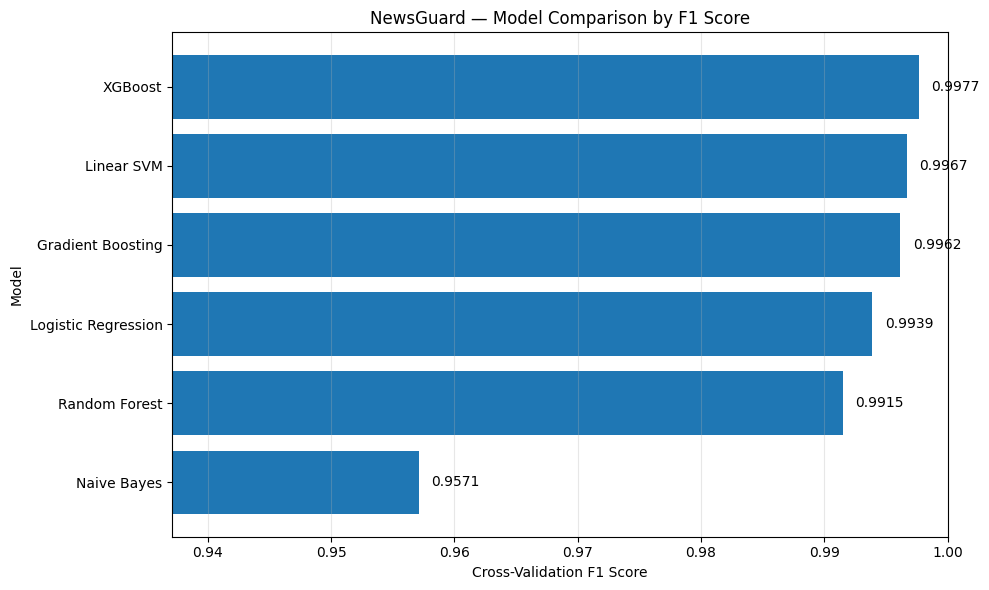


✅ Model comparison image saved:
/content/drive/MyDrive/NewsGuard/results/day_07/model_comparison_f1.png
✅ MODEL COMPARISON RESULT IMAGE GENERATED


In [6]:
# CELL 6 — MODEL COMPARISON CHART

print("DAY 7 — MODEL COMPARISON VISUALIZATION")
print("=" * 70)

# Load Day 6 model comparison
comparison_df = pd.read_csv(
    f"{BASE}/results/day_06_model_comparison.csv"
)

# Add Day 5 models if not already present
baseline_df = pd.read_csv(
    f"{BASE}/results/day_05_baseline_results.csv"
)

# Normalize model column names if needed
comparison_df.columns = comparison_df.columns.str.strip()
baseline_df.columns = baseline_df.columns.str.strip()

print("\nDay 6 models:")
print(comparison_df)

print("\nDay 5 baseline models:")
print(baseline_df)

# Prepare F1 comparison
day6_plot = comparison_df[["Model", "CV_F1"]].copy()

day5_plot = baseline_df[["Model", "CV_F1"]].copy()

model_comparison = pd.concat(
    [day5_plot, day6_plot],
    ignore_index=True
)

# Remove duplicate models
model_comparison = model_comparison.drop_duplicates(
    subset="Model",
    keep="first"
)

# Sort by F1
model_comparison = model_comparison.sort_values(
    "CV_F1",
    ascending=True
)

print("\nFINAL MODEL COMPARISON")
print("-" * 70)
print(model_comparison.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    model_comparison["Model"],
    model_comparison["CV_F1"]
)

plt.xlabel("Cross-Validation F1 Score")
plt.ylabel("Model")
plt.title("NewsGuard — Model Comparison by F1 Score")

plt.xlim(
    max(0, model_comparison["CV_F1"].min() - 0.02),
    1.0
)

# Add values
for i, value in enumerate(model_comparison["CV_F1"]):
    plt.text(
        value + 0.001,
        i,
        f"{value:.4f}",
        va="center"
    )

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

comparison_path = (
    f"{results_dir}/model_comparison_f1.png"
)

plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print(f"✅ Model comparison image saved:")
print(comparison_path)
print("✅ MODEL COMPARISON RESULT IMAGE GENERATED")

In [7]:
# CELL 7 — SAVE COMPLETE DAY 7 RESULTS

print("DAY 7 — SAVING FINAL EVALUATION RESULTS")
print("=" * 70)

day7_results = {
    "Model": "XGBoost",
    "Validation_Accuracy": val_accuracy,
    "Validation_Precision": val_precision,
    "Validation_Recall": val_recall,
    "Validation_F1": val_f1,
    "Validation_ROC_AUC": val_roc_auc,
    "Test_Accuracy": test_accuracy,
    "Test_Precision": test_precision,
    "Test_Recall": test_recall,
    "Test_F1": test_f1,
    "Test_ROC_AUC": test_roc_auc,
    "Test_Fake_Support": int((y_test == 0).sum()),
    "Test_Real_Support": int((y_test == 1).sum()),
    "CV_Best_F1": 0.997701,
    "Target_F1": 0.88,
    "Target_Achieved": bool(test_f1 > 0.88)
}

# Save CSV
day7_results_df = pd.DataFrame([day7_results])

csv_path = f"{results_dir}/day_07_final_results.csv"
day7_results_df.to_csv(csv_path, index=False)

# Save Joblib
joblib_path = f"{results_dir}/day_07_final_results.joblib"
joblib.dump(day7_results, joblib_path)

# Save confusion matrix
cm_path_csv = f"{results_dir}/day_07_confusion_matrix.csv"
pd.DataFrame(
    cm,
    index=["Actual_Fake", "Actual_Real"],
    columns=["Predicted_Fake", "Predicted_Real"]
).to_csv(cm_path_csv)

print("\nFINAL DAY 7 RESULTS")
print("-" * 70)

for key, value in day7_results.items():
    print(f"{key}: {value}")

print("\n" + "=" * 70)
print("Saved files:")
print(f"✅ {csv_path}")
print(f"✅ {joblib_path}")
print(f"✅ {cm_path_csv}")

print("\n" + "=" * 70)
print("✅ DAY 7 FINAL RESULTS SAVED")
print("✅ F1 TARGET > 0.88 ACHIEVED")
print("✅ DAY 7 EVALUATION COMPLETE")

DAY 7 — SAVING FINAL EVALUATION RESULTS

FINAL DAY 7 RESULTS
----------------------------------------------------------------------
Model: XGBoost
Validation_Accuracy: 0.9966751918158567
Validation_Precision: 0.9948308270676691
Validation_Recall: 0.999056158565361
Validation_F1: 0.9969390157758418
Validation_ROC_AUC: 0.9997565300151852
Test_Accuracy: 0.9971874200971619
Test_Precision: 0.995768688293371
Test_Recall: 0.9990566037735849
Test_F1: 0.9974099364257123
Test_ROC_AUC: 0.9997803482822919
Test_Fake_Support: 1791
Test_Real_Support: 2120
CV_Best_F1: 0.997701
Target_F1: 0.88
Target_Achieved: True

Saved files:
✅ /content/drive/MyDrive/NewsGuard/results/day_07/day_07_final_results.csv
✅ /content/drive/MyDrive/NewsGuard/results/day_07/day_07_final_results.joblib
✅ /content/drive/MyDrive/NewsGuard/results/day_07/day_07_confusion_matrix.csv

✅ DAY 7 FINAL RESULTS SAVED
✅ F1 TARGET > 0.88 ACHIEVED
✅ DAY 7 EVALUATION COMPLETE
